# Mobile Price Classification

Bob has started his own mobile company. He wants to give tough fight to big companies like Apple,Samsung etc.

He does not know how to estimate price of mobiles his company creates. In this competitive mobile phone market you cannot simply assume things. To solve this problem he collects sales data of mobile phones of various companies.

Source data url:
https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification/data

# Part 1. Problem Definition
In this problem you do not have to predict actual price but a price range indicating how high the price is

# Part 2. Data

The dataset i have been using is from train.csv that i downloaded from kaggle form the mentioned source url

# Part 3. Evaluation
If the model can reach 60% or more higher Kappa Statistic then we will be pursue the model

source: https://www.statology.org/cohens-kappa-statistic/

# Part 4. Feature
The feature of dataset is

1. **battery_power**
Total energy a battery can store in one time measured in mAh
2. **blue**
Has bluetooth or not
3. **clock_speed**
speed at which microprocessor executes instructions
4. **dual_sim**
Has dual sim support or not
5. **fc**
Front Camera mega pixels
6. **four_g**
Has 4G or not
7. **int_memory**
Internal Memory in Gigabytes
8. **m_dep**
Mobile Depth in cm
9. **mobile_wt**
Weight of mobile phone
10. **n_cores**
Number of cores of processor
11. **pc**
Primary Camera mega pixels
12. **px_height**
Pixel Resolution Height
13. **px_width**
Pixel Resolution Width
14. **ram**
Random Access Memory in Mega Bytes
15. **sc_h**
Screen Height of mobile in cm
16. **sc_w**
Screen Width of mobile in cm
17. **talk_time**
longest time that a single battery charge will last when you are
18. **three_g**
Has 3G or not
19. **touch_screen**
Has touch screen or not
20. **wifi**
Has wifi or not
21. **price_range**
This is the target variable with value of 0(low cost), 1(medium cost), 2(high cost) and 3(very high cost).

# Preparing the tools
We're going to use pandas, Matplotlib and NumPy for data analysis and manipulation.

In [1]:
# Import all the tools we need

# Regular EDA (exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import json library
import json

# we want our plots to appear inside the notebook 
%matplotlib inline

# Models from Scikit-Learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

# Model evaluation
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# Load data

In [2]:
df = pd.read_csv("dataset/train.csv")
print(df.shape) # (rows, columns)

(2000, 21)


# Data Exploration (exploratory data analysis or EDA)
1. What question(s) are you trying to solve (or prove wrong)?
2. What kind of data do you have and how do you treat different types?
3. What's missing from the data and how do you deal with it?
4. Where are the outliers and why should you care about them?
5. How can you add, change or remove features to get more out of your data?

In [3]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [5]:
df.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


In [7]:
# Check the target variable portion
df["price_range"].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

<Axes: xlabel='price_range'>

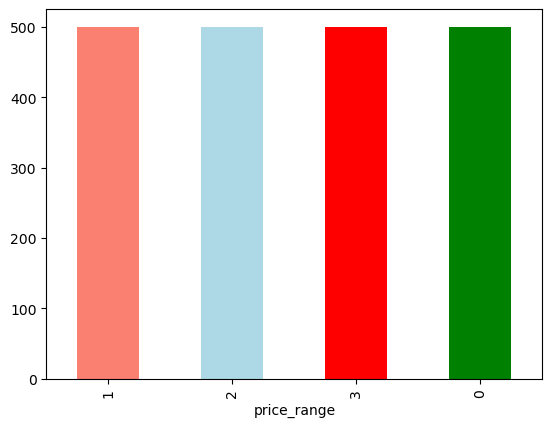

In [8]:
df["price_range"].value_counts().plot(kind="bar", color=["salmon", "lightblue", "red", "green"])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [10]:
# check the missing values
df.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [11]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


# EDA Level
1) EDA Level 0 — Pure Understanding of Original Data
2) EDA Level 1 — Transformation of Original Data
3) EDA Level 2 — Understanding of Transformed Data

source: https://medium.com/data-and-beyond/mastering-exploratory-data-analysis-eda-everything-you-need-to-know-7e3b48d63a95

### EDA Level 0 — Pure Understanding of Original Data

In [12]:
# Check the column datatype, null counts, and distinct values

def column_summary(df):
    summary_data = []

    for col_name in df.columns:
        col_dtype = df[col_name].dtype
        num_of_nulls = df[col_name].isnull().sum()
        num_of_non_nulls = df[col_name].notnull().sum()
        num_of_distinct_values = df[col_name].nunique()
        
        if num_of_distinct_values <= 10:
            distinct_values_counts = df[col_name].value_counts().to_dict()
        else:
            top_10_values_counts = df[col_name].value_counts().head(10).to_dict()
            distinct_values_counts = {k: v for k, v in sorted(top_10_values_counts.items(), key=lambda item:item[1], reverse=True)}

        summary_data.append({
            'col_name': col_name,
            'col_dtype': col_dtype,
            'num_of_nulls': num_of_nulls,
            'num_of_non_nulls': num_of_non_nulls,
            'num_of_distinct_values': num_of_distinct_values,
            'distinct_values_counts': distinct_values_counts
        })

    summary_df = pd.DataFrame(summary_data)
    return summary_df

# Example usage:
# Assuming df is your DataFrame
summary_df = column_summary(df)
display(summary_df)

,col_name,col_dtype,num_of_nulls,num_of_non_nulls,num_of_distinct_values,distinct_values_counts
0,battery_power,int64,0,2000,1094,"{1872: 6, 618: 6, 1589: 6, 1715: 5, 1807: 5, 1..."
1,blue,int64,0,2000,2,"{0: 1010, 1: 990}"
2,clock_speed,float64,0,2000,26,"{0.5: 413, 2.8: 85, 2.3: 78, 2.1: 76, 1.6: 76,..."
3,dual_sim,int64,0,2000,2,"{1: 1019, 0: 981}"
4,fc,int64,0,2000,20,"{0: 474, 1: 245, 2: 189, 3: 170, 5: 139, 4: 13..."
5,four_g,int64,0,2000,2,"{1: 1043, 0: 957}"
6,int_memory,int64,0,2000,63,"{27: 47, 16: 45, 14: 45, 57: 42, 2: 42, 42: 40..."
7,m_dep,float64,0,2000,10,"{0.1: 320, 0.2: 213, 0.8: 208, 0.5: 205, 0.7: ..."
8,mobile_wt,int64,0,2000,121,"{182: 28, 101: 27, 185: 27, 146: 26, 199: 26, ..."
9,n_cores,int64,0,2000,8,"{4: 274, 7: 259, 8: 256, 2: 247, 3: 246, 5: 24..."


##### Extract more info

In [13]:
# Gets additional value such as min / median / max etc.
def column_summary_plus(df):
    result_df = pd.DataFrame(columns=['col_name','col_dtype','num_distinct_values','min_value','max_value'])
    
    # Loop through each column in the DataFrame
    for column in df.columns:
        print(f"Start processing {column} col with {df[column].dtype} dtype")
        # Get column dtype
        col_dtype = df[column].dtype
        # Get distinct values and their counts
        value_counts = df[column].value_counts()
        distinct_values = value_counts.index.tolist()
        # Get number of distinct values
        num_distinct_values = len(distinct_values)
        # Get min and max values
        sorted_values = sorted(distinct_values)
        min_value = sorted_values[0] if sorted_values else None
        max_value = sorted_values[-1] if sorted_values else None
        
        # Get median value
        non_distinct_val_list = sorted(df[column].dropna().tolist())
        len_non_d_list = len(non_distinct_val_list)
        if len(non_distinct_val_list) == 0:
            median = None
        else:
            median = non_distinct_val_list[len_non_d_list//2]

        # Get average value if value is number
        if np.issubdtype(df[column].dtype, np.number):
            if len(non_distinct_val_list) > 0:
                average = sum(non_distinct_val_list)/len_non_d_list
                non_zero_val_list = [v for v in non_distinct_val_list if v > 0]
                average_non_zero = sum(non_zero_val_list)/len_non_d_list
            else:
                average = None
                average_non_zero = None
        else:
            average = None
            average_non_zero = None

        # Check if null values are present
        null_present = 1 if df[column].isnull().any() else 0

        # Get number of nulls and non-nulls
        num_nulls = df[column].isnull().sum()
        num_non_nulls = df[column].notnull().sum()

        # Distinct_values only take top 10 distinct values count
        top_10_d_v = value_counts.head(10).index.tolist()
        top_10_c = value_counts.head(10).tolist()
        top_10_d_v_dict = dict(zip(top_10_d_v, top_10_c))

        # Prepare a dictionary for the row to be added
        row = {'col_name': column,
               'col_dtype': col_dtype,
               'num_distinct_values': num_distinct_values,
               'min_value': min_value,
               'max_value': max_value,
               'median_no_na': median,
               'average_no_na': average,
               'average_non_zero': average_non_zero,
               'null_present': null_present,
               'nulls_num': num_nulls,
               'non_nulls_num': num_non_nulls,
               'distinct_values': top_10_d_v
        }
        
        # Convert the dictionary to a DataFrame and concatenate with result_df
        result_df = pd.concat([result_df, pd.DataFrame([row])], ignore_index=True)

    return result_df 

summary_df = column_summary_plus(df)
display(summary_df)

Start processing battery_power col with int64 dtype
Start processing blue col with int64 dtype
Start processing clock_speed col with float64 dtype
Start processing dual_sim col with int64 dtype
Start processing fc col with int64 dtype
Start processing four_g col with int64 dtype
Start processing int_memory col with int64 dtype
Start processing m_dep col with float64 dtype
Start processing mobile_wt col with int64 dtype
Start processing n_cores col with int64 dtype
Start processing pc col with int64 dtype
Start processing px_height col with int64 dtype
Start processing px_width col with int64 dtype
Start processing ram col with int64 dtype
Start processing sc_h col with int64 dtype
Start processing sc_w col with int64 dtype
Start processing talk_time col with int64 dtype
Start processing three_g col with int64 dtype
Start processing touch_screen col with int64 dtype
Start processing wifi col with int64 dtype
Start processing price_range col with int64 dtype


,col_name,col_dtype,num_distinct_values,min_value,max_value,median_no_na,average_no_na,average_non_zero,null_present,nulls_num,non_nulls_num,distinct_values
0,battery_power,int64,1094,501,1998,1227.0,1238.51850,1238.51850,0.0,0.0,2000.0,"[1872, 618, 1589, 1715, 1807, 1310, 1083, 1512..."
1,blue,int64,2,0,1,0.0,0.49500,0.49500,0.0,0.0,2000.0,"[0, 1]"
2,clock_speed,float64,26,0.5,3.0,1.5,1.52225,1.52225,0.0,0.0,2000.0,"[0.5, 2.8, 2.3, 2.1, 1.6, 2.5, 0.6, 1.4, 1.3, ..."
3,dual_sim,int64,2,0,1,1.0,0.50950,0.50950,0.0,0.0,2000.0,"[1, 0]"
4,fc,int64,20,0,19,3.0,4.30950,4.30950,0.0,0.0,2000.0,"[0, 1, 2, 3, 5, 4, 6, 7, 9, 8]"
5,four_g,int64,2,0,1,1.0,0.52150,0.52150,0.0,0.0,2000.0,"[1, 0]"
6,int_memory,int64,63,2,64,32.0,32.04650,32.04650,0.0,0.0,2000.0,"[27, 16, 14, 57, 2, 42, 7, 44, 30, 6]"
7,m_dep,float64,10,0.1,1.0,0.5,0.50175,0.50175,0.0,0.0,2000.0,"[0.1, 0.2, 0.8, 0.5, 0.7, 0.3, 0.9, 0.6, 0.4, ..."
8,mobile_wt,int64,121,80,200,141.0,140.24900,140.24900,0.0,0.0,2000.0,"[182, 101, 185, 146, 199, 88, 198, 105, 89, 131]"
9,n_cores,int64,8,1,8,4.0,4.52050,4.52050,0.0,0.0,2000.0,"[4, 7, 8, 2, 3, 5, 1, 6]"


In [14]:
### To Save Pandas to CSV
def dtype_to_json(pdf, json_file_path: str) -> dict:
    '''
    Parameters
    ----------
    pdf : pandas.DataFrame
        pandas.DataFrame so we can extract the dtype
    json_file_path : str
        the json file path location
        
    Returns
    -------
    Dict
        The dtype dictionary used
    
    To create a json file which stores the pandas dtype dictionary for
    use when converting back from csv to pandas.DataFrame.
    '''
    dtype_dict = pdf.dtypes.apply(lambda x: str(x)).to_dict()

    with open(json_file_path, 'w') as json_file:
        json.dump(dtype_dict, json_file)

    return dtype_dict

def download_csv_json(df, mainpath):
        csvpath = f"{mainpath}.csv"
        jsonfp = f"{mainpath}_dtype.json"
    
        dtypedict = dtype_to_json(df, jsonfp)
        df.to_csv(csvpath, index=False)
    
        return csvpath, jsonfp

# Example usage:
download_csv_json(df, "C:/Users/Phincon/Project-Machine Learning/file_1")

### To Load CSV to Pandas
def json_to_dtype(jsonfilepath):
    with open(jsonfilepath, 'r') as json_file:
        loaded_dict = json.load(json_file)
    return loaded_dict

# def csv_to_pandas(csvpath, jsonpath):
def csv_to_pandas(csvpath, jsonpath):
    dtypedict = json_to_dtype(jsonpath)
    pdf = pd.read_csv(csvpath,dtype=dtypedict)
    
    return pdf

# Example usage:
csvfp = 'C:/Users/Phincon/Project-Machine Learning/file_1.csv'
jsonfp = 'C:/Users/Phincon/Project-Machine Learning/file_1_dtype.json'
df = csv_to_pandas(csvfp, jsonfp)

In [15]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
print(df.head())
print(df.describe())
print(df.duplicated().sum())

   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  mobile_wt  n_cores  pc  px_height  px_width   ram  sc_h  sc_w  talk_time  three_g  touch_screen  wifi  price_range
0            842     0          2.2         0   1       0           7    0.6        188        2   2         20       756  2549     9     7         19        0             0     1            1
1           1021     1          0.5         1   0       1          53    0.7        136        3   6        905      1988  2631    17     3          7        1             1     0            2
2            563     1          0.5         1   2       1          41    0.9        145        5   6       1263      1716  2603    11     2          9        1             1     0            2
3            615     1          2.5         0   0       0          10    0.8        131        6   9       1216      1786  2769    16     8         11        1             0     0            2
4           1821     1          1.2

The code above is for:
1) Get an idea how the dataset looks like
2) Know the median / mean / rough statistical distribution
3) Check that there are no duplicated rows.

# Check the distribution

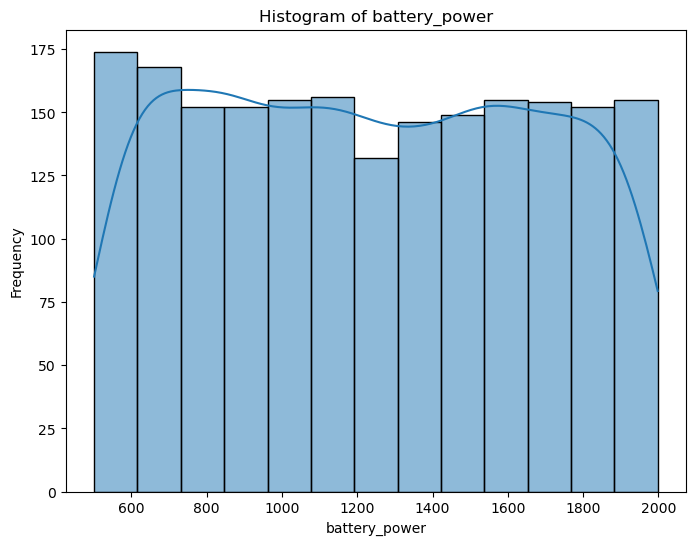

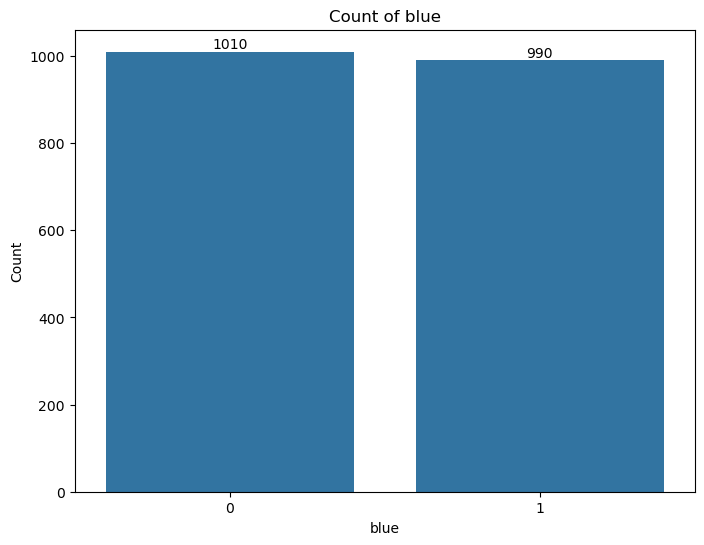

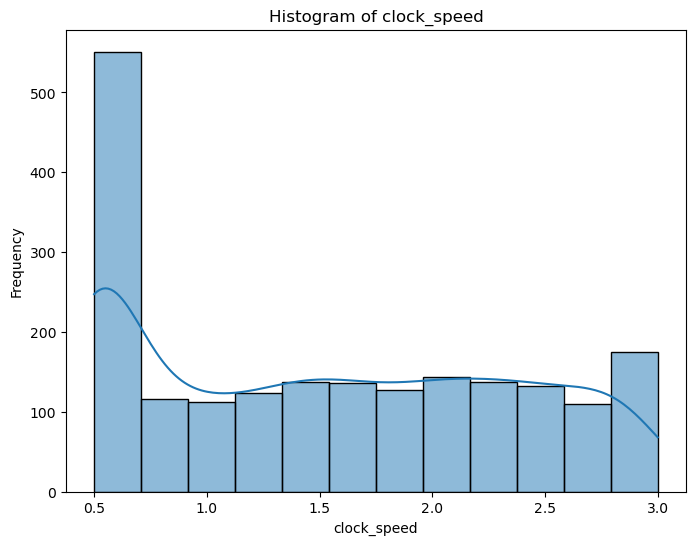

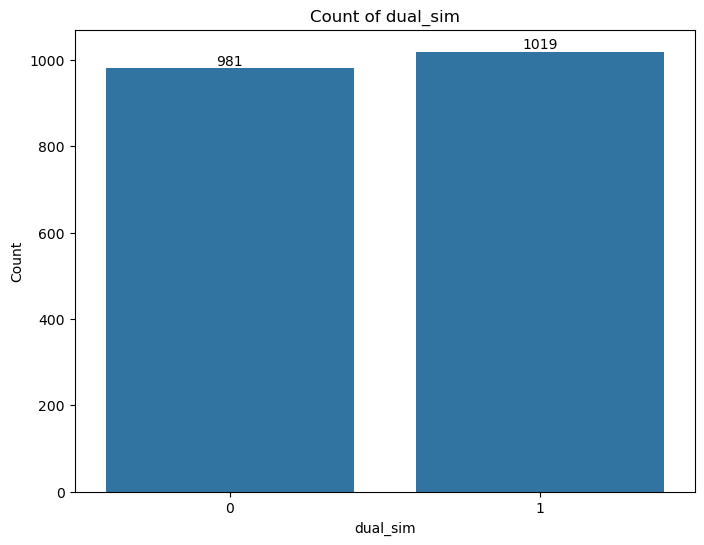

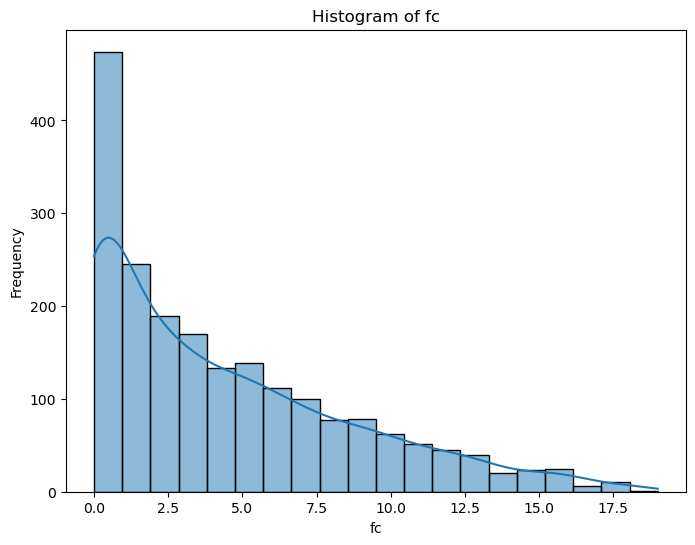

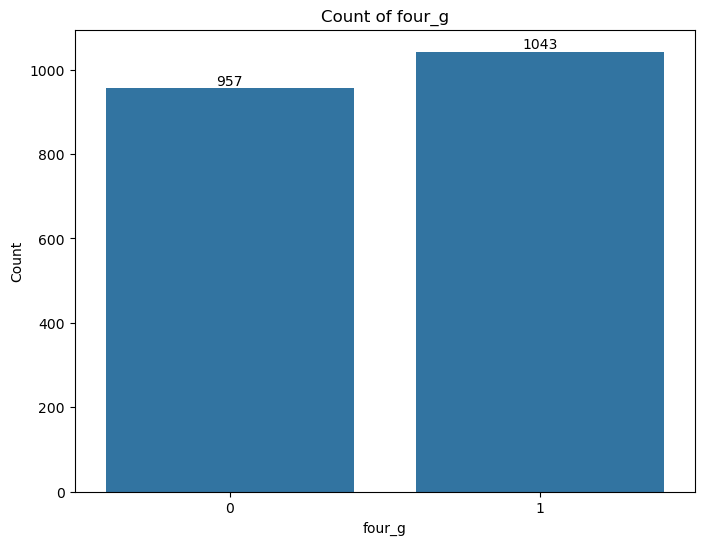

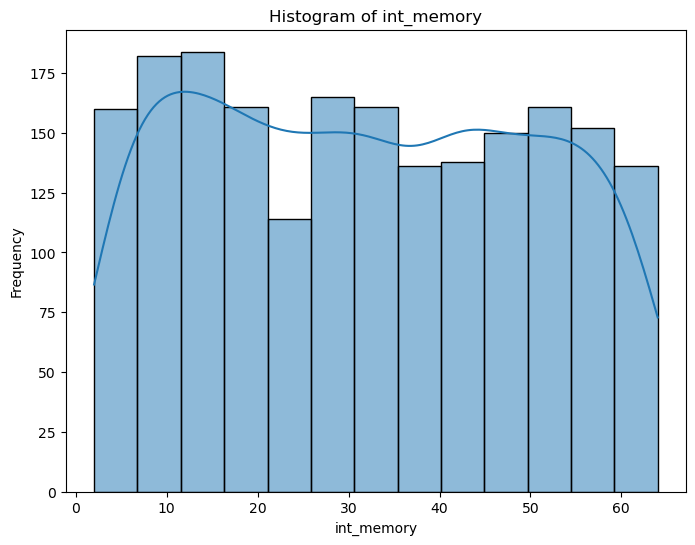

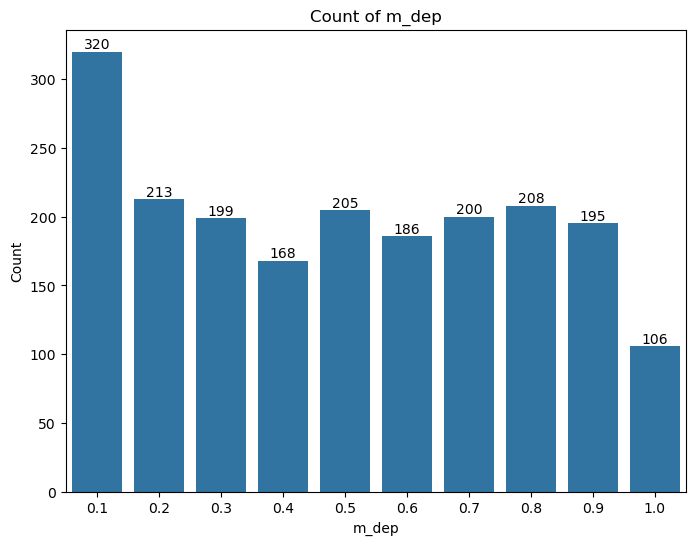

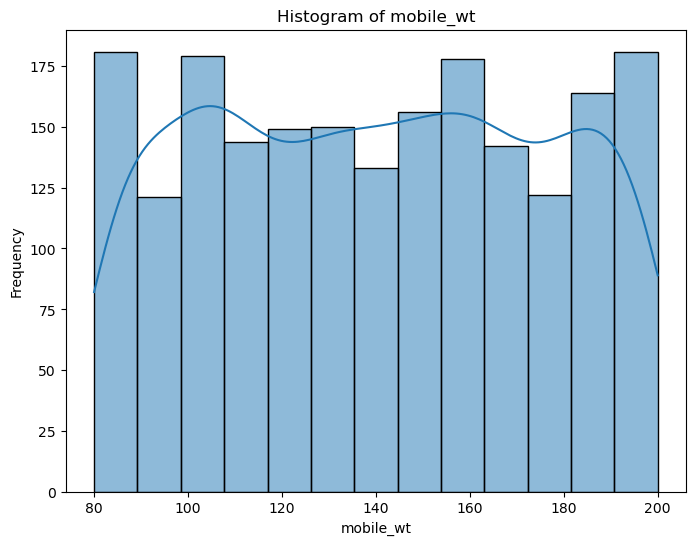

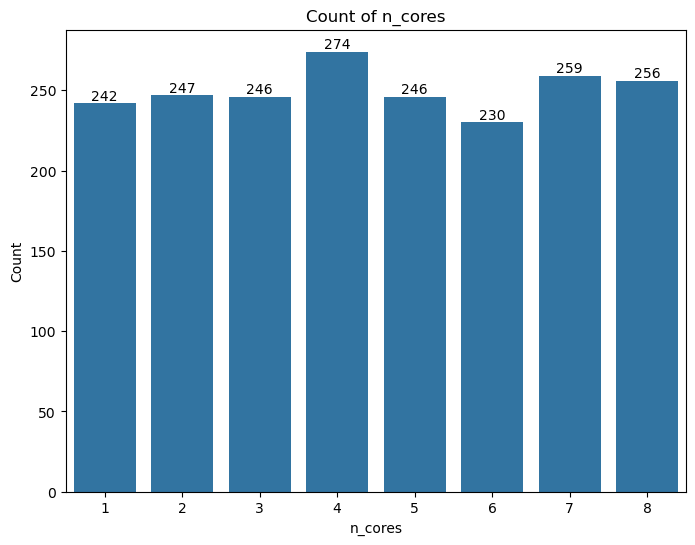

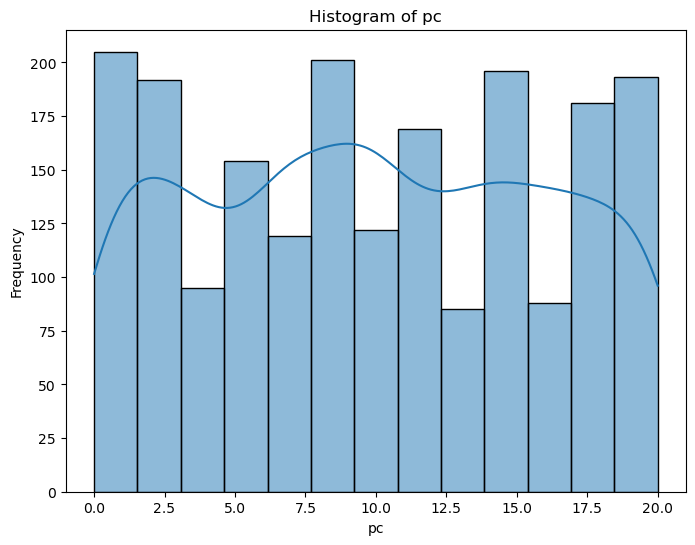

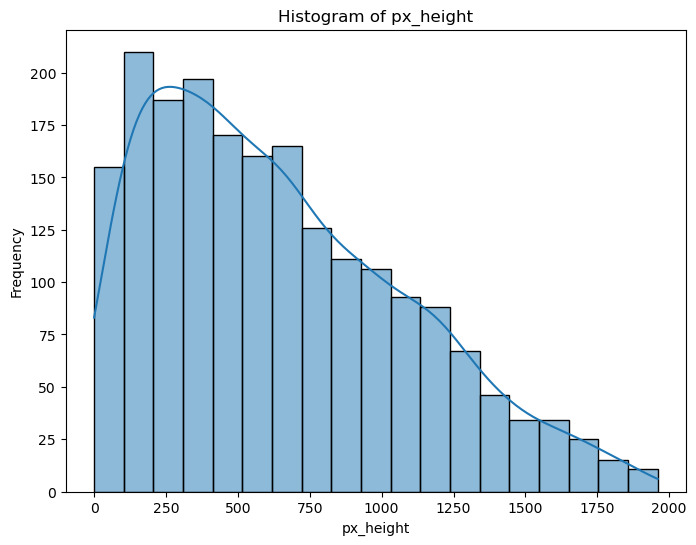

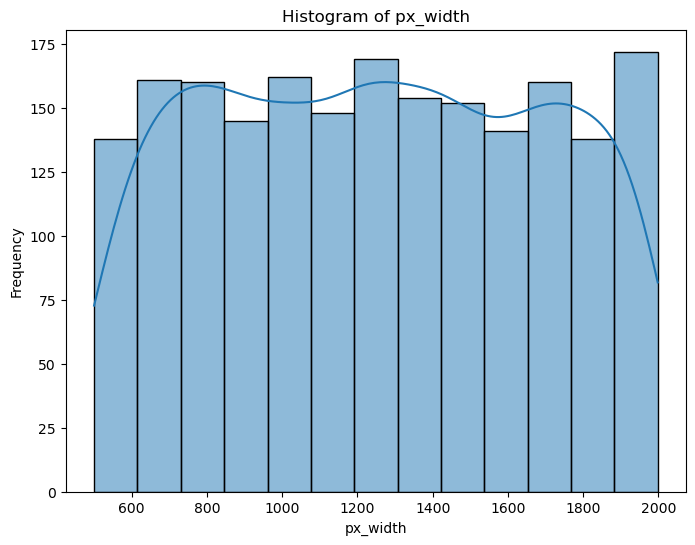

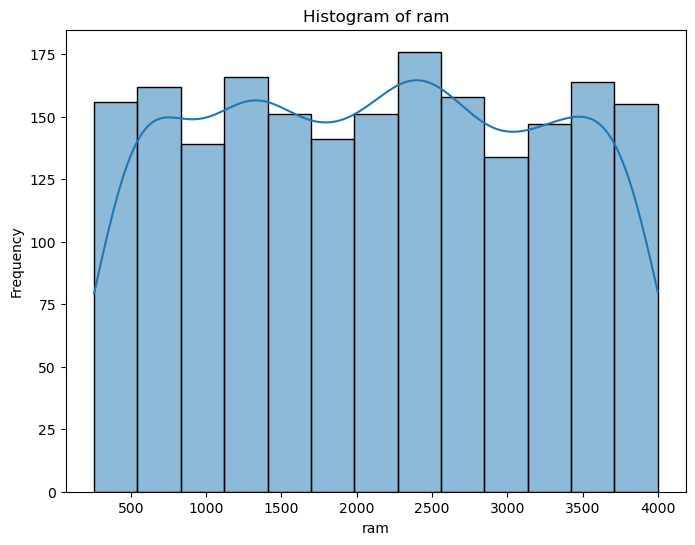

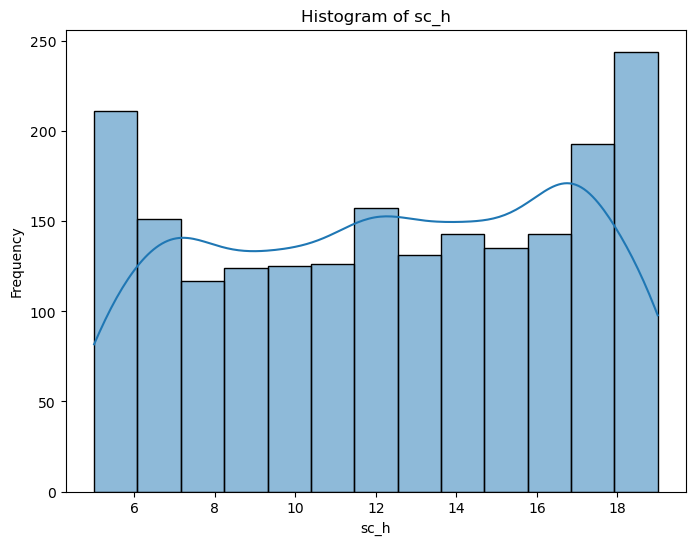

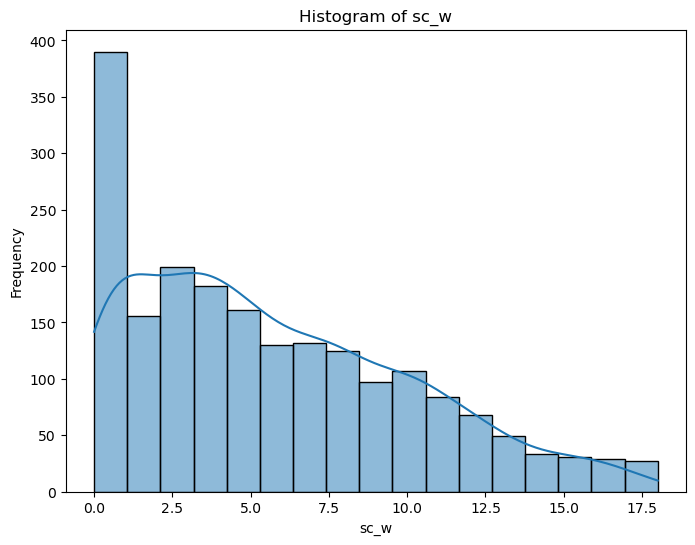

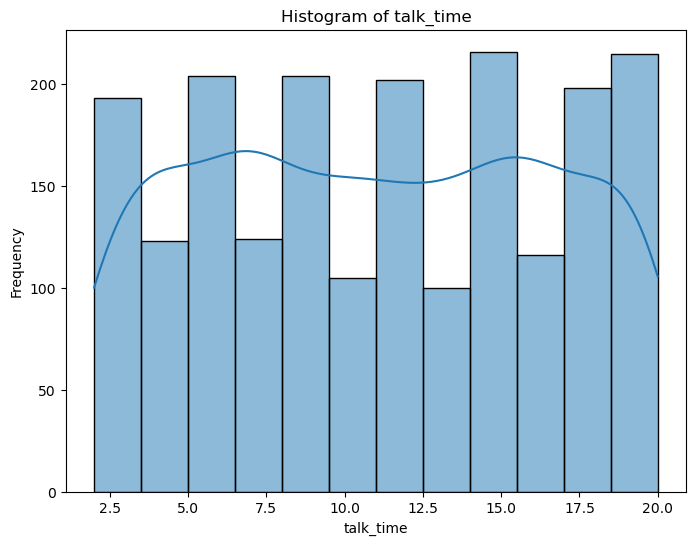

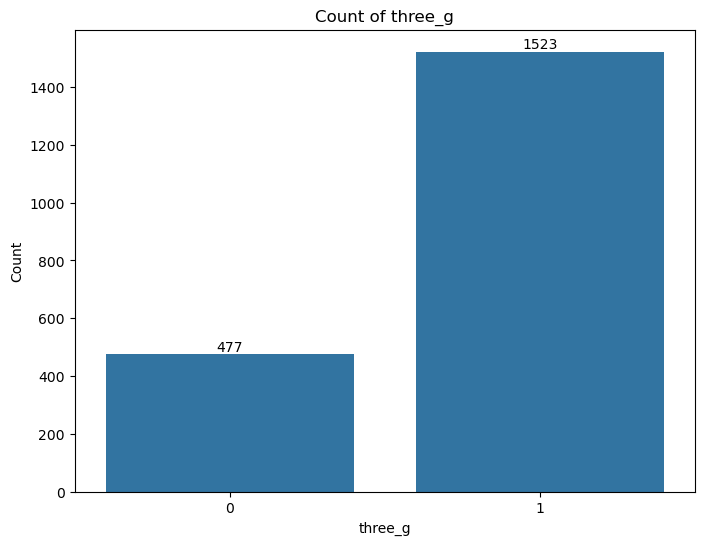

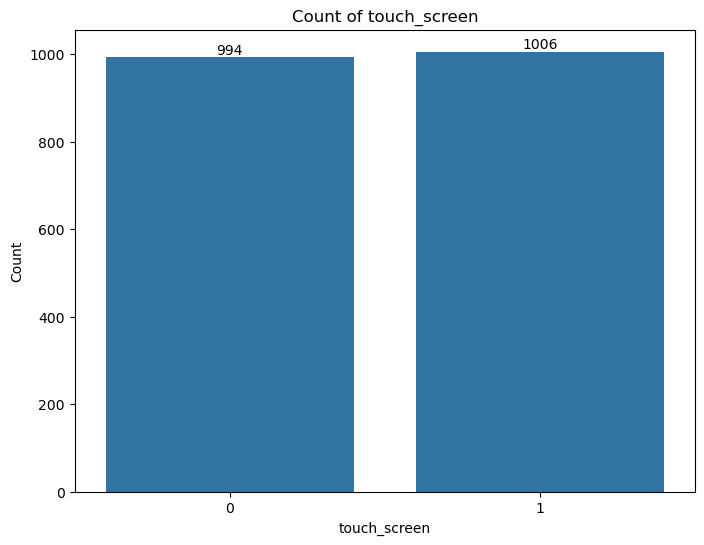

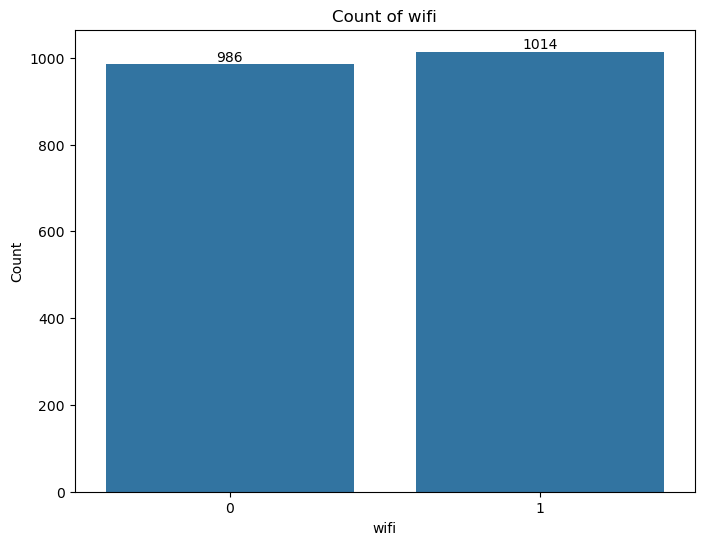

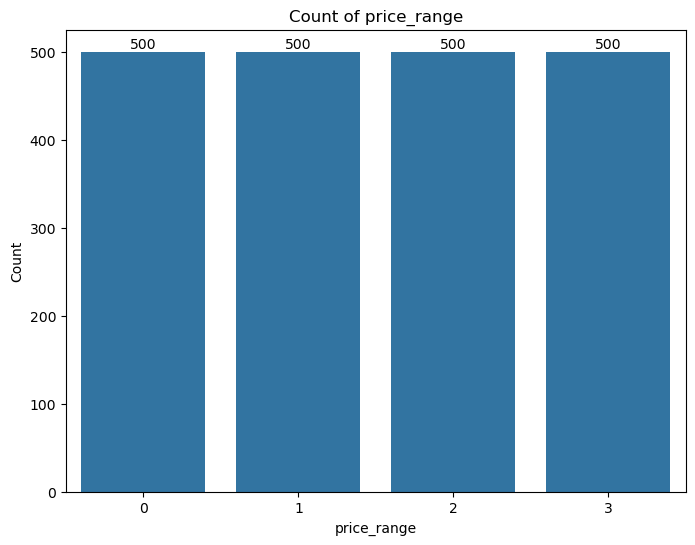

In [23]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=[np.number]).columns

# Perform univariate analysis on numerical columns
for column in numerical_columns:
     # For continuous variables
     if len(df[column].unique()) > 10: # Assuming if unique values > 10, consider it continuous
        plt.figure(figsize=(8, 6))
        sns.histplot(df[column], kde=True)
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show()
     else: # For discrete or ordinal variables
        plt.figure(figsize=(8,6))
        ax = sns.countplot(x=column, data=df)
        plt.title(f'Count of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')

        # Annotate each bar with its count
        for p in ax.patches:
            ax.annotate(format(p.get_height(),'.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0,5),
                        textcoords = 'offset points')
        plt.show()

In [20]:
print(df.columns)

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range'], dtype='object')


## EDA Level 1 — Transformation of Original Data